In [1]:
import numpy as np
import pandas as pd
from sklearn import set_config
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    OneHotEncoder, StandardScaler, MinMaxScaler, FunctionTransformer
)
from scipy.stats import pearsonr, spearmanr
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import norm
from constants import CATEGORICAL_COLS 

In [2]:
def load_classification_data(delta, is_sigma=True):
    df = pd.read_csv("cleaned_t2dm_a2h_eda.tsv", sep='\t')
    df = df.set_index("group_id")
    delta_data = df['result']
    if is_sigma:
        sigma = np.array(delta_data).std()
        print('Sigma: ', sigma)
        delta = delta * sigma
    print('Delta: ', delta)
    df["result_translation"] = df['result'].abs().apply(lambda x: 1 if x < delta else 0)
    df = df.drop(columns=['result'])
    inputs = df.drop(columns=['result_translation'])
    labels = df['result_translation']
    return inputs, labels

In [3]:
def load_data_transformed():

    def _get_fs(method_name):
        """Get the scaling pipeline."""
        if method_name == 'standard':
            return StandardScaler()
        elif method_name == 'minmax':
            return MinMaxScaler()
        elif method_name == 'none':
            return FunctionTransformer(feature_names_out='one-to-one')
        else:
            raise ValueError(f"Unknown scaling method: {method_name}")


    def _get_ohe(categories):
        """Get the pipeline for one-hot encoding."""
        return OneHotEncoder(
            categories=categories,
            drop='if_binary',
            handle_unknown='ignore',
            sparse_output=False,
        )

    def get_ft_pipeline(
        data,
        scaling_method_name,
        categorical_features=[],
    ):
        """Get the pipeline for feature transformation. The feature
        transformation includes scaling for numerical and one-hot encoding for
        categorical features.
        """
        return ColumnTransformer(
            transformers=[
                (f'ohe_{i}', _get_ohe([np.sort(data[col].unique())]), [col])
                if col in categorical_features else
                (f'scaler_{i}', _get_fs(scaling_method_name), [col])
                for i, col in enumerate(data.columns)
            ],
        )

    def _get_simple_pipeline(
        data,
        categorical_features=[]
    ):
        """Get the pipeline for mean/mode imputation."""
        return Pipeline([
            ('simple', ColumnTransformer(
                transformers=[
                    (
                        f"mode_{i}",
                        SimpleImputer(strategy='most_frequent'),
                        [col],
                    ) if col in categorical_features else
                    (
                        f"mean_{i}",
                        SimpleImputer(strategy='mean'),
                        [col],
                    ) for i, col in enumerate(data.columns)
                ],
                verbose_feature_names_out=False,
            )),
        ])


    def get_mvi_pipeline(method_name, params={}):
        """Get the pipeline for missing value imputation.
        """
        if method_name == 'simple':
            return _get_simple_pipeline(**params)
        else:
            raise ValueError(f'Invalid method name: {method_name}')

    inputs, labels = load_classification_data(delta=0.5, is_sigma=True)
    inputs = inputs.drop(columns=['intervention'])
    # print(type(inputs))
    
    mvi_pipeline = get_mvi_pipeline( method_name='simple',
                                    params={
                                        'data': inputs,
                                        'categorical_features': CATEGORICAL_COLS,
                                    })
    
    imputed_inputs = mvi_pipeline.fit_transform(inputs)
    
    # After fit_transform with ColumnTransformer (SimpleImputer only)
    imputed_inputs = pd.DataFrame(imputed_inputs, columns=inputs.columns, index=inputs.index)
    # print(imputed_inputs)
    ft_pipeline = get_ft_pipeline(
                data=imputed_inputs,
                scaling_method_name='none',
                categorical_features=CATEGORICAL_COLS,
            )
    ft_inputs = ft_pipeline.fit_transform(imputed_inputs)
    
    feature_names = ft_pipeline.get_feature_names_out()
    X_df = pd.DataFrame(ft_inputs, columns=feature_names, index=inputs.index)
    return X_df, labels

In [4]:
data_transformed, labels = load_data_transformed()

Sigma:  2.071823354291777
Delta:  1.0359116771458885


In [5]:
data_transformed

,scaler_0__preclinical_dosage_amount_value,ohe_1__preclinical_dosage_amount_unit_% (w/w),ohe_1__preclinical_dosage_amount_unit_g/kg,ohe_1__preclinical_dosage_amount_unit_mg/kg,ohe_1__preclinical_dosage_amount_unit_nmol/kg,ohe_1__preclinical_dosage_amount_unit_pm/kg/min,ohe_1__preclinical_dosage_amount_unit_μg/kg,ohe_2__preclinical_administration_route_Unknown,ohe_2__preclinical_administration_route_gastric intubation,ohe_2__preclinical_administration_route_gavage,...,scaler_15__clinical_sample_size,scaler_16__clinical_dosage_amount(mg),ohe_17__clinical_dosage_frequency_1+every1days,ohe_17__clinical_dosage_frequency_1+every7days,ohe_17__clinical_dosage_frequency_2+every1days,ohe_17__clinical_dosage_frequency_3+every1days,ohe_17__clinical_dosage_frequency_Unknown,scaler_18__clinical_dosage_duration(days),scaler_19__clinical_total_doses,scaler_20__clinical_total_dosage(mg)
group_id,,,,,,,,,,,,,,,,,,,,,
PMC4000968_NCT00086515,10.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,453.0,100.0,1.0,0.0,0.0,0.0,0.0,168.0,168.0,16800.0
PMC3998187_NCT00086515,10.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,453.0,100.0,1.0,0.0,0.0,0.0,0.0,168.0,168.0,16800.0
PMC2905949_NCT00086515,10.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,453.0,100.0,1.0,0.0,0.0,0.0,0.0,168.0,168.0,16800.0
PMC3235777_NCT00086515,10.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,453.0,100.0,1.0,0.0,0.0,0.0,0.0,168.0,168.0,16800.0
PMC4514850_NCT00086515,100.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,453.0,100.0,1.0,0.0,0.0,0.0,0.0,168.0,168.0,16800.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
PMC8975272_NCT05486065,15.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,56.0,2.0,0.0,1.0,0.0,0.0,0.0,280.0,40.0,80.0
PMC8975272_NCT05486065,15.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,56.0,16.0,0.0,1.0,0.0,0.0,0.0,280.0,40.0,640.0
PMC7383507_NCT05659537,0.6,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,189.0,1.5,0.0,1.0,0.0,0.0,0.0,168.0,24.0,36.0


In [6]:
labels

group_id
PMC4000968_NCT00086515    1
PMC3998187_NCT00086515    0
PMC2905949_NCT00086515    1
PMC3235777_NCT00086515    0
PMC4514850_NCT00086515    1
                         ..
PMC8975272_NCT05486065    1
PMC8975272_NCT05486065    1
PMC7383507_NCT05659537    1
PMC9796023_NCT05659537    1
PMC8975272_NCT05659537    1
Name: result_translation, Length: 2898, dtype: int64

In [7]:
def plot_corr_heatmap(X, y, method='pearson', path_save_dir="."):
    """
    """
    data = pd.concat([X, y], axis=1)
    corr = data.corr(method=method)

    if method == 'pearson':
        p_val = data.corr(method=lambda x, y: pearsonr(x, y)[1])
    elif method == 'spearman':
        p_val = data.corr(method=lambda x, y: spearmanr(x, y)[1])
    else:
        raise ValueError(f"Unknown correlation method: {method}")

    corr_result = pd.concat(
        [corr['result_translation'], p_val['result_translation']], axis=1
    )
    corr_result.columns = ['corr', 'p_val']
    corr_result = corr_result.sort_values(
        by='p_val', ascending=True
    )
    corr_result.to_csv(f"{path_save_dir}/corr_result_{method}.csv")

In [8]:
plot_corr_heatmap(data_transformed, labels)

In [9]:
plot_corr_heatmap(data_transformed, labels, 'spearman')

In [ ]:
def plot_corr_bar_top_10(method='pearson', path_save_dir="."):
    data_corr = pd.read_csv(f"./corr_result_{method}.csv", index_col=0)
    data_corr = data_corr.sort_values(
        by='corr', key=abs, ascending=False
    ).iloc[1:11]

    data_corr.index = [
        x.split("__")[-1] for x in data_corr.index
    ]
    data_corr['color'] = [
        'orange' if x < 0 else 'lightblue' for x in data_corr['corr']
    ]
    plt.figure(figsize=(12, 8))

    g = sns.barplot(
        data=data_corr,
        y=data_corr.index,
        x='corr',
        palette=data_corr['color'].tolist(),
    )
    plt.axvline(x=0, color='black', linewidth=1)
    g.set_xlabel('Correlation coefficient')
    g.set_ylabel('Feature')
    g.set_xticklabels(
        g.get_xticklabels()
    )

    plt.title(f"{method}'s coefficient analysis")
    plt.savefig(f"{path_save_dir}/corr_result_top_10_{method}.png", bbox_inches='tight', dpi=300)

    pass

/tmp/ipykernel_1495796/3738427309.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  g = sns.barplot(
/tmp/ipykernel_1495796/3738427309.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels(


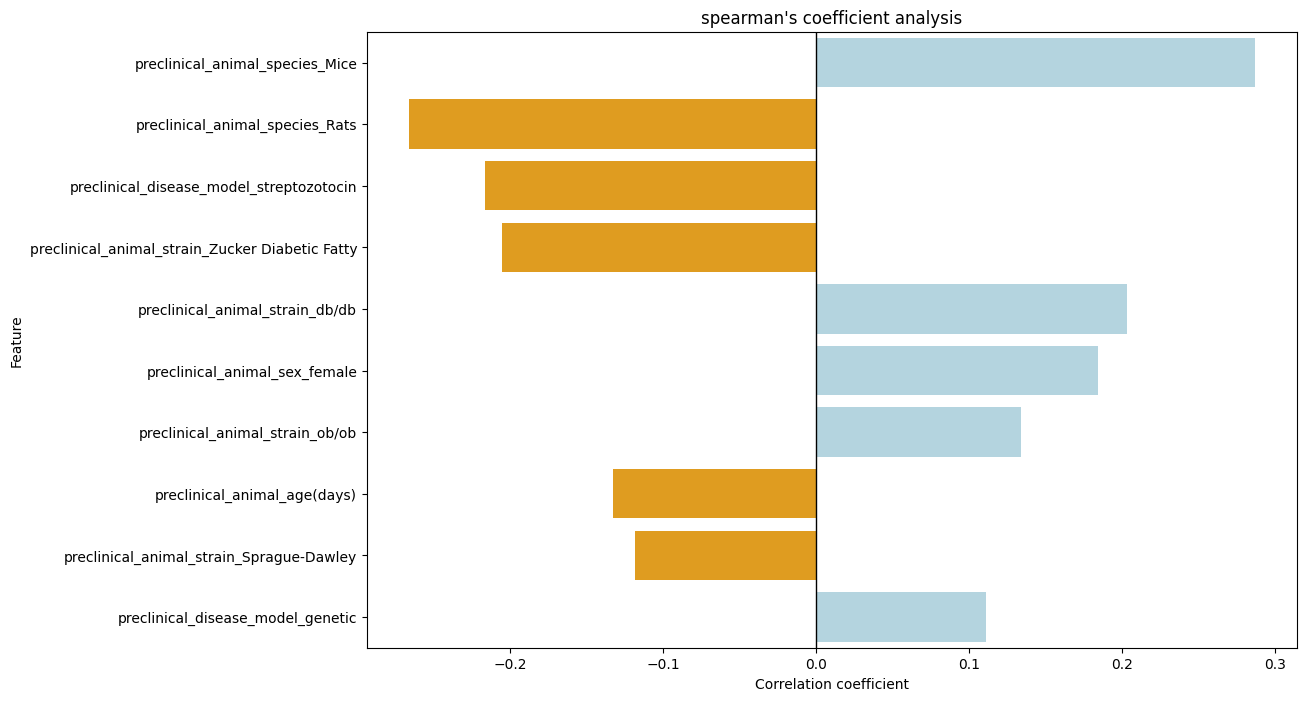

In [11]:
plot_corr_bar_top_10('spearman')